# GOLDEN 01_setup_and_datasets

**Thesis section:** `sec:setup:*` (Chapter 4 — System and Experimental Setup: `sec:setup:notation`, `sec:setup:protocol`, `sec:setup:datasets`, `sec:setup:design`)
**Provenance:** Chapter 4 is almost entirely DESIGN CONSTANTS and dataset facts, not computed statistics. Tier-3 screening logic ported from `notebooks/008v2 Task Difficulty Tiers (4-tier).ipynb` (`assign_tier`), REPOINTED off the deleted scan dirs onto the surviving `*_subset_scan_nothink_small` dirs.
**Data:** `results/mas/final_dataset_new_system` (the frozen 21,000-rep corpus); `results/mas/gpqa_subset_scan_nothink_small` + `results/mas/hiddenbench_subset_scan_nothink_small` (screening pass).
**Figures exported to:** none — Chapter 4 has no `\includegraphics`; the tier diagnostic plot is shown inline only.
**Status:** design constants VERIFIED by arithmetic + corpus counting. Tier-3 35-task selection is a FROZEN ARTIFACT (screening source data deleted; HiddenBench scan empty) — see note in Part 3.

This is a GOLDEN notebook. Chapter 4 states no estimated statistics: every number is either a design/config choice (agent count, round cap, memory windows, temperature, option counts) or a corpus fact (file counts, rep counts, task-id sets). This notebook (a) documents each design constant as a design choice, (b) VERIFIES the arithmetic the chapter asserts (message counts, config count, total-rep product), and (c) CONFIRMS the committed corpus by counting files, repetitions, and the actual task-id sets. Numbers are printed in labelled blocks for manual copy into the thesis. See `notebooks/golden/INDEX.md` for the full section->notebook map.


## Design constants and dataset facts (Chapter 4)

These are **choices**, not computed results. Recorded here so the notebook has a single authoritative table; the code cells below only verify the arithmetic and the corpus that follow from them.

**System model (`sec:setup:notation`)**
- $N = 4$ agents throughout (line ~70, ~131, ~524).
- $M$ = answer options, $M \in \{3, 4\}$; independent of $N$ (line ~76, ~487).
- Fully-connected (fc): $N(N-1) = 12$ messages per round for $N=4$ (line ~109).
- Star: $2(N-1) = 6$ messages per round for $N=4$ (line ~114).

**Protocol (`sec:setup:protocol`)**
- Confidence $c_i^t \in \{1,\ldots,10\}$ (line ~78).
- Two-phase rounds (\arguephase{}/\updatephase{}); round 0 is \updatephase{}-only.
- Memory window $W$, early-stop threshold $u = 3$, hard cap $T = 15$ (line ~382, ~526).
- Pilot self-loop probability $0.97$–$1.00$ for unanimous states (hand-stated pilot number, line ~376).

**Datasets (`sec:setup:datasets`)**
- GPQA-Diamond: 198 questions, four-option MC ($M = 4$) (line ~438, ~443).
- HiddenBench: $N = 4$, $M \in \{3, 4\}$ (line ~487).

**Experimental design (`sec:setup:design`)**
- Scan axes: $W \in \{1, 2, 5\}$ and topology $\in \{\textsc{fc}, \textsc{star}\}$; product $3 \times 2 = 6$ configs per task (line ~510, ~518).
- Fixed: $N = 4$; $T = 15$ (cap), $u = 3$; model `mistral-medium-instruct`; temperature $0.7$, reasoning disabled (line ~524–538).
- Final corpus: **35 tasks per benchmark $\times$ 2 benchmarks $\times$ 6 configs $\times$ 50 reps $= 35 \times 2 \times 6 \times 50 = 21{,}000$ repetitions** (line ~586–588).
- Screening pass: single baseline config (fc, $W=1$, $R=3$) (line ~570–571).
- Runtime estimate: ~$25$ s/rep; full GPQA grid ~ten days at $R=30$ (HAND-STATED, non-reproducible — see note).


In [1]:
import sys
sys.path.insert(0, '../..')

import json
from pathlib import Path
from collections import Counter as _Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE      = Path('../..') / 'results' / 'mas' / 'final_dataset_new_system'
GPQA_SCAN = Path('../..') / 'results' / 'mas' / 'gpqa_subset_scan_nothink_small'
HB_SCAN   = Path('../..') / 'results' / 'mas' / 'hiddenbench_subset_scan_nothink_small'

# Design constants (from Chapter 4)
N          = 4
T_CAP      = 15
U_STOP     = 3
W_VALUES   = [1, 2, 5]
TOPOS      = ['fc', 'star']
DATASETS   = ['gpqa', 'hiddenbench']
TEMPERATURE = 0.7
MODEL       = 'mistral-medium'

from src.viz.thesis_style import (apply_style, W_COLORS, DS_LABELS, T_LABELS, no_grid)
apply_style()
print('setup ok')

setup ok


In [2]:
# ── sec:setup ARITHMETIC VERIFICATION (design constants — pure arithmetic) ──
print('=' * 60)
print('ARITHMETIC VERIFICATION of Chapter 4 design constants')
print('=' * 60)

# --- sec:setup:notation L109 fully-connected messages N(N-1) ---
fc_msgs = N * (N - 1)
print(f'--- sec:setup:notation L109 fc messages ---')
print(f'  N(N-1) = {N}*{N-1} = {fc_msgs}   thesis_says=12   {"MATCH" if fc_msgs==12 else "MISMATCH"}')

# --- sec:setup:notation L114 star messages 2(N-1) ---
star_msgs = 2 * (N - 1)
print(f'--- sec:setup:notation L114 star messages ---')
print(f'  2(N-1) = 2*{N-1} = {star_msgs}   thesis_says=6   {"MATCH" if star_msgs==6 else "MISMATCH"}')
print(f'  star is half of fc: {star_msgs} == {fc_msgs}//2 -> {star_msgs == fc_msgs//2}')

# --- sec:setup:design L518 configs = |W| * |topology| ---
n_configs = len(W_VALUES) * len(TOPOS)
print(f'--- sec:setup:design L518 configs ---')
print(f'  |W| x |topo| = {len(W_VALUES)}*{len(TOPOS)} = {n_configs}   thesis_says=6   {"MATCH" if n_configs==6 else "MISMATCH"}')

# --- sec:setup:design L586-588 total repetitions ---
N_TASKS_PER_DS = 35
N_DS           = 2
R_DEEP         = 50
total_reps = N_TASKS_PER_DS * N_DS * n_configs * R_DEEP
print(f'--- sec:setup:design L586-588 total repetitions ---')
print(f'  35 x 2 x 6 x 50 = {N_TASKS_PER_DS}*{N_DS}*{n_configs}*{R_DEEP} = {total_reps:,}   '
      f'thesis_says=21,000   {"MATCH" if total_reps==21000 else "MISMATCH"}')

# --- sec:setup:design L570-571 screening config ---
print(f'--- sec:setup:design L570-571 screening config (fc, W=1, R=3) ---')
print(f'  documented as design choice: topology=fc, W=1, R=3')

ARITHMETIC VERIFICATION of Chapter 4 design constants
--- sec:setup:notation L109 fc messages ---
  N(N-1) = 4*3 = 12   thesis_says=12   MATCH
--- sec:setup:notation L114 star messages ---
  2(N-1) = 2*3 = 6   thesis_says=6   MATCH
  star is half of fc: 6 == 12//2 -> True
--- sec:setup:design L518 configs ---
  |W| x |topo| = 3*2 = 6   thesis_says=6   MATCH
--- sec:setup:design L586-588 total repetitions ---
  35 x 2 x 6 x 50 = 35*2*6*50 = 21,000   thesis_says=21,000   MATCH
--- sec:setup:design L570-571 screening config (fc, W=1, R=3) ---
  documented as design choice: topology=fc, W=1, R=3


In [3]:
# ── sec:setup:design CORPUS CONFIRMATION (frozen 21,000-rep dataset) ──
# Count files, reps/file, and the datasets/topologies/W actually present.
files = sorted(BASE.glob('**/*.json'))
print('=' * 60)
print('CORPUS CONFIRMATION: results/mas/final_dataset_new_system')
print('=' * 60)

meta_rows = []
rep_counts = []
for f in files:
    d = json.loads(f.read_text())
    nrep = len(d['repetitions'])
    rep_counts.append(nrep)
    meta_rows.append({
        'dataset': d['dataset'],
        'topology': d.get('topology_name', 'fc'),
        'W': d['W'],
        'qid': int(d['question_id']),
        'N': d['N'],
        'T': d['T'],
        'u': d.get('early_stopping_u'),
        'temperature': d['temperature'],
        'model': d['model'],
        'M': len(d['options']),
        'n_reps': nrep,
    })
meta = pd.DataFrame(meta_rows)

# --- sec:setup:design L586-588 file count ---
n_files = len(files)
exp_files = 35 * 2 * 6
print(f'--- file count (35 tasks x 2 datasets x 6 configs) ---')
print(f'  files={n_files}   expected={exp_files}   {"MATCH" if n_files==exp_files else "MISMATCH"}')

# --- reps per file ---
uniq_reps = sorted(set(rep_counts))
print(f'--- reps per file (expected 50) ---')
print(f'  distinct rep-counts across files = {uniq_reps}   '
      f'{"MATCH (all 50)" if uniq_reps==[50] else "MISMATCH"}')
print(f'  total repetitions = sum(reps) = {sum(rep_counts):,}   '
      f'thesis_says=21,000   {"MATCH" if sum(rep_counts)==21000 else "MISMATCH"}')

# --- datasets / topologies / W present ---
print(f'--- axes present ---')
print(f'  datasets   = {sorted(meta.dataset.unique())}   expected {DATASETS}')
print(f'  topologies = {sorted(meta.topology.unique())}   expected {TOPOS}')
print(f'  W values   = {sorted(meta.W.unique())}   expected {W_VALUES}')
print(f'  N values   = {sorted(meta.N.unique())}   expected [4]')
print(f'  T values   = {sorted(meta["T"].unique())}   expected [15]')
print(f'  u values   = {sorted(meta.u.dropna().unique())}   expected [3]')
print(f'  temperature= {sorted(meta.temperature.unique())}   expected [0.7]')
print(f'  model      = {sorted(meta.model.unique())}   expected [mistral-medium]')

CORPUS CONFIRMATION: results/mas/final_dataset_new_system


--- file count (35 tasks x 2 datasets x 6 configs) ---
  files=420   expected=420   MATCH
--- reps per file (expected 50) ---
  distinct rep-counts across files = [50]   MATCH (all 50)
  total repetitions = sum(reps) = 21,000   thesis_says=21,000   MATCH
--- axes present ---
  datasets   = ['gpqa', 'hiddenbench']   expected ['gpqa', 'hiddenbench']
  topologies = ['fc', 'star']   expected ['fc', 'star']
  W values   = [np.int64(1), np.int64(2), np.int64(5)]   expected [1, 2, 5]
  N values   = [np.int64(4)]   expected [4]
  T values   = [np.int64(15)]   expected [15]
  u values   = [np.int64(3)]   expected [3]
  temperature= [np.float64(0.7)]   expected [0.7]
  model      = ['mistral-medium']   expected [mistral-medium]


In [4]:
# ── sec:setup:datasets M (option-count) confirmation ──
print('=' * 60)
print('OPTION-COUNT (M) CONFIRMATION per dataset')
print('=' * 60)

# --- sec:setup:datasets:gpqa L443 GPQA M=4 ---
gpqa_M = sorted(meta[meta.dataset == 'gpqa'].M.unique())
print(f'--- sec:setup:datasets:gpqa L443 GPQA option count ---')
print(f'  GPQA M values = {gpqa_M}   thesis_says M=4   {"MATCH" if gpqa_M==[4] else "MISMATCH"}')

# --- sec:setup:datasets:hiddenbench L487 HiddenBench M in {3,4} ---
hb_M = sorted(meta[meta.dataset == 'hiddenbench'].M.unique())
hb_M_dist = _Counter(meta[(meta.dataset=='hiddenbench') & (meta.W==1) & (meta.topology=='fc')].M)
print(f'--- sec:setup:datasets:hiddenbench L487 HiddenBench option count ---')
print(f'  HiddenBench M values = {hb_M}   thesis_says M in {{3,4}}   '
      f'{"MATCH" if set(hb_M)<= {3,4} and len(hb_M)>1 else "CHECK"}')
print(f'  HiddenBench M distribution (W1/fc, 35 tasks): {dict(hb_M_dist)}')

# --- design cross-check: 6 configs actually present per (dataset, qid) ---
cfg_per_task = (meta.groupby(['dataset','qid'])[['W','topology']]
                    .apply(lambda g: len(g.drop_duplicates()))
                    .rename('n_configs'))
print(f'--- configs per task (expected 6 for every task) ---')
print(f'  distinct config-counts per task = {sorted(cfg_per_task.unique())}   '
      f'{"MATCH (all 6)" if list(cfg_per_task.unique())==[6] else "MISMATCH"}')
print(f'  tasks per dataset: '
      f"gpqa={meta[meta.dataset=='gpqa'].qid.nunique()}, "
      f"hiddenbench={meta[meta.dataset=='hiddenbench'].qid.nunique()}   expected 35 each")

OPTION-COUNT (M) CONFIRMATION per dataset
--- sec:setup:datasets:gpqa L443 GPQA option count ---
  GPQA M values = [np.int64(4)]   thesis_says M=4   MATCH
--- sec:setup:datasets:hiddenbench L487 HiddenBench option count ---
  HiddenBench M values = [np.int64(3), np.int64(4)]   thesis_says M in {3,4}   MATCH
  HiddenBench M distribution (W1/fc, 35 tasks): {3: 31, 4: 4}
--- configs per task (expected 6 for every task) ---
  distinct config-counts per task = [np.int64(6)]   MATCH (all 6)
  tasks per dataset: gpqa=35, hiddenbench=35   expected 35 each


In [5]:
# ── sec:setup:design ACTUAL TASK-ID SET per dataset (the frozen selection) ──
print('=' * 60)
print('FROZEN TASK-ID SET (final_dataset_new_system) — 35 GPQA + 35 HiddenBench')
print('=' * 60)

for ds in DATASETS:
    qids = sorted(meta[meta.dataset == ds].qid.unique())
    print(f'--- {DS_LABELS[ds]} ({len(qids)} tasks) ---')
    print(f'  {qids}')
    print()

# Sanity: qid sets are identical across all 6 configs within a dataset
print('Per-config qid-set consistency (all 6 configs must share the same 35 qids):')
for ds in DATASETS:
    sets = []
    for w in W_VALUES:
        for topo in TOPOS:
            s = frozenset(meta[(meta.dataset==ds)&(meta.W==w)&(meta.topology==topo)].qid)
            sets.append((w, topo, s))
    ref = sets[0][2]
    consistent = all(s == ref for _, _, s in sets)
    print(f'  {DS_LABELS[ds]:12s} all-6-configs-identical={consistent}  n_qids={len(ref)}')

FROZEN TASK-ID SET (final_dataset_new_system) — 35 GPQA + 35 HiddenBench
--- GPQA (35 tasks) ---
  [np.int64(3), np.int64(5), np.int64(12), np.int64(23), np.int64(24), np.int64(26), np.int64(33), np.int64(35), np.int64(50), np.int64(73), np.int64(79), np.int64(80), np.int64(84), np.int64(86), np.int64(90), np.int64(91), np.int64(95), np.int64(98), np.int64(99), np.int64(109), np.int64(111), np.int64(117), np.int64(125), np.int64(132), np.int64(136), np.int64(144), np.int64(146), np.int64(149), np.int64(152), np.int64(157), np.int64(164), np.int64(166), np.int64(173), np.int64(179), np.int64(182)]

--- HiddenBench (35 tasks) ---
  [np.int64(1), np.int64(2), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(25), np.int64(28), np.int64(31), np.int64(34), np.int64(35), np.int64(37), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np

---
## Part 3 — Tier-3 selection (`sec:setup:design`): REPOINTED screening reproduction

**Provenance.** The 4-tier screening lived in `notebooks/008v2 Task Difficulty Tiers (4-tier).ipynb`, reading `results/mas/gpqa_subset_scan` and `results/mas/hiddenbench_subset_scan`. **Both source dirs were deleted.** We REPOINT to the surviving screening dirs `results/mas/gpqa_subset_scan_nothink_small` and `results/mas/hiddenbench_subset_scan_nothink_small`, which match the chapter's stated screening config (fc, $W=1$, $R=3$; model `mistral-small` — the ledger confirms `mistral-small` was the active screening model).

**`assign_tier` logic (ported verbatim from 008v2):**
- **Tier 0 (trivial):** unanimous at $t=0$ AND zero flips.
- **Tier 1 (easy):** mean trajectory length $\leq 4$ rounds.
- **Tier 2 (moderate):** debate occurs but no outcome variance across reps (final majority always the same option).
- **Tier 3 (hard):** debate occurs AND the final answer varies across reps.

The cell below reruns `assign_tier` on whatever screening data survives and reports the 4-tier counts.


In [6]:
# ── sec:setup:design TIER-3 SCREENING (ported assign_tier from 008v2) ──
def votes_at(rep, t):
    return [a['vote'] for a in rep['trajectory'][t]['phase_b']]

def count_flips(rep):
    traj = rep['trajectory']
    total = 0
    for ag in range(len(traj[0]['phase_b'])):
        for t in range(1, len(traj)):
            if traj[t-1]['phase_b'][ag]['vote'] != traj[t]['phase_b'][ag]['vote']:
                total += 1
    return total

def question_stats(d):
    reps = d['repetitions']; gt = d['ground_truth']; T_max = d['T']
    rep_stats, final_majorities = [], []
    for rep in reps:
        Tr = len(rep['trajectory'])
        v0 = votes_at(rep, 0); vf = votes_at(rep, Tr - 1)
        majority = max(set(vf), key=vf.count); final_majorities.append(majority)
        rep_stats.append({
            'initial_unanimous': len(set(v0)) == 1,
            'flips': count_flips(rep),
            'trajectory_len': Tr,
        })
    return {
        'qid': int(d['question_id']),
        'n_reps': len(rep_stats),
        'initial_unanimous_rate': float(np.mean([r['initial_unanimous'] for r in rep_stats])),
        'mean_flips': float(np.mean([r['flips'] for r in rep_stats])),
        'mean_trajectory_len': float(np.mean([r['trajectory_len'] for r in rep_stats])),
        'outcome_variance': len(set(final_majorities)) > 1,
    }

def assign_tier(row):
    if row['initial_unanimous_rate'] == 1.0 and row['mean_flips'] == 0.0:
        return 0
    if row['mean_trajectory_len'] <= 4.0:
        return 1
    if not row['outcome_variance']:
        return 2
    return 3

def load_scan(directory):
    files = sorted(directory.glob('*.json'))
    by_qid, paths = {}, {}
    for f in files:
        d = json.loads(f.read_text())
        qid = int(d['question_id'])
        if qid not in by_qid or str(f) > paths[qid]:
            by_qid[qid] = d; paths[qid] = str(f)
    return by_qid

TIER_LABELS = {0: 'Trivial', 1: 'Easy', 2: 'Moderate', 3: 'Hard'}
scan_dfs = {}
for ds, scan_dir in [('gpqa', GPQA_SCAN), ('hiddenbench', HB_SCAN)]:
    raw = load_scan(scan_dir)
    print(f'--- {DS_LABELS[ds]} screening: {len(raw)} questions in {scan_dir.name} ---')
    if not raw:
        print(f'  EMPTY / MISSING -> tiers not reproducible for {DS_LABELS[ds]} (see frozen-artifact note)')
        scan_dfs[ds] = None
        continue
    model_used = sorted({d['model'] for d in raw.values()})
    cfg_used   = sorted({(d.get('topology_name'), d['W'], d['R']) for d in raw.values()})
    print(f'  screening model = {model_used}   config (topo,W,R) = {cfg_used}')
    df = pd.DataFrame([question_stats(d) for d in raw.values()])
    df['tier'] = df.apply(assign_tier, axis=1)
    df = df.sort_values('qid').reset_index(drop=True)
    scan_dfs[ds] = df
    counts = df['tier'].value_counts().sort_index()
    for t, n in counts.items():
        print(f'    Tier {t} ({TIER_LABELS[t]}): {n}  ({100*n/len(df):.1f}%)')
    tier3 = sorted(df[df.tier == 3].qid.tolist())
    print(f'    Tier-3 qids ({len(tier3)}): {tier3}')

--- GPQA screening: 58 questions in gpqa_subset_scan_nothink_small ---
  screening model = ['mistral-small']   config (topo,W,R) = [('fc', 1, 3)]
    Tier 0 (Trivial): 3  (5.2%)
    Tier 1 (Easy): 11  (19.0%)
    Tier 2 (Moderate): 11  (19.0%)
    Tier 3 (Hard): 33  (56.9%)
    Tier-3 qids (33): [1, 2, 5, 8, 9, 10, 11, 13, 15, 17, 22, 23, 24, 25, 27, 28, 30, 32, 33, 34, 35, 36, 37, 38, 41, 42, 44, 47, 48, 50, 52, 54, 56]
--- HiddenBench screening: 0 questions in hiddenbench_subset_scan_nothink_small ---
  EMPTY / MISSING -> tiers not reproducible for HiddenBench (see frozen-artifact note)


In [7]:
# ── Reconcile screening Tier-3 set with the FROZEN final-dataset selection ──
print('=' * 60)
print('FROZEN-ARTIFACT RECONCILIATION')
print('=' * 60)
for ds in DATASETS:
    final_qids = set(meta[meta.dataset == ds].qid.unique())
    print(f'--- {DS_LABELS[ds]} ---')
    print(f'  final_dataset qids (n={len(final_qids)}): {sorted(final_qids)}')
    df = scan_dfs.get(ds)
    if df is None:
        print(f'  screening data unavailable -> cannot reproduce selection; final set is frozen.')
        continue
    tier3 = set(df[df.tier == 3].qid.tolist())
    inter = final_qids & tier3
    print(f'  screening Tier-3 qids (n={len(tier3)}): {sorted(tier3)}')
    print(f'  final ∩ screening-Tier3 = {len(inter)} / {len(final_qids)} final tasks')
    print(f'  final \\ screening-Tier3 = {sorted(final_qids - tier3)}  '
          f'(present in final but not Tier-3 under repointed screening)')

FROZEN-ARTIFACT RECONCILIATION
--- GPQA ---
  final_dataset qids (n=35): [np.int64(3), np.int64(5), np.int64(12), np.int64(23), np.int64(24), np.int64(26), np.int64(33), np.int64(35), np.int64(50), np.int64(73), np.int64(79), np.int64(80), np.int64(84), np.int64(86), np.int64(90), np.int64(91), np.int64(95), np.int64(98), np.int64(99), np.int64(109), np.int64(111), np.int64(117), np.int64(125), np.int64(132), np.int64(136), np.int64(144), np.int64(146), np.int64(149), np.int64(152), np.int64(157), np.int64(164), np.int64(166), np.int64(173), np.int64(179), np.int64(182)]
  screening Tier-3 qids (n=33): [1, 2, 5, 8, 9, 10, 11, 13, 15, 17, 22, 23, 24, 25, 27, 28, 30, 32, 33, 34, 35, 36, 37, 38, 41, 42, 44, 47, 48, 50, 52, 54, 56]
  final ∩ screening-Tier3 = 6 / 35 final tasks
  final \ screening-Tier3 = [np.int64(3), np.int64(12), np.int64(26), np.int64(73), np.int64(79), np.int64(80), np.int64(84), np.int64(86), np.int64(90), np.int64(91), np.int64(95), np.int64(98), np.int64(99), np.in

### Frozen-artifact note (per plan Q2)

The exact **35-task selection cannot be reproduced** from committed data, for two reasons:

1. **Screening source deleted.** The chapter's screening ran on `gpqa_subset_scan` / `hiddenbench_subset_scan` (now deleted). The repointed `*_subset_scan_nothink_small` dirs are the closest surviving proxy, but the GPQA scan uses `mistral-small` (not the deep-pass `mistral-medium`) and covers a different question set/size, and the **HiddenBench scan directory is empty**, so HiddenBench tiers are not reproducible at all.
2. **Random retention.** Even given a Tier-3 pool, the chapter draws 35 GPQA tasks **uniformly at random** from the eligible Tier-3 set (GPQA yields more than 35), so the specific 35 are a stochastic draw with no committed seed.

The `final_dataset_new_system` task-id set (printed above) is therefore treated as a **frozen artifact**: it is the authoritative selection used throughout `sec:results`, and the reconciliation cell above documents how it relates to the repointed screening rather than regenerating it.

### Non-reproducible runtime estimates

The runtime figures in `sec:setup:design` (~$25$ s per repetition; the full GPQA grid taking on the order of ten days at $R=30$) are **hand-stated planning estimates**, not measured quantities. They depend on API latency at collection time and are not reproducible from committed data; they are recorded here only for provenance. The committed JSON files do carry a `total_duration_s` field per task, but it reflects wall-clock at collection (including retries/throttling) and is not the basis of the chapter's estimate.


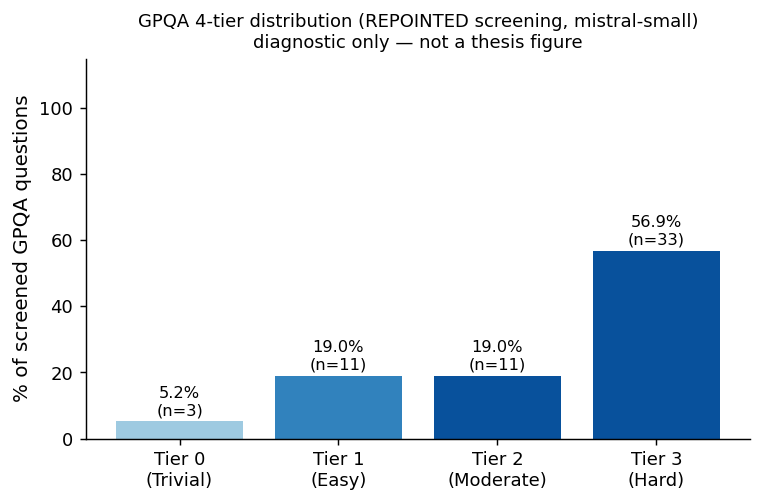

In [8]:
# Diagnostic figure (NOT a thesis figure — Chapter 4 has no \includegraphics).
# GPQA-only tier distribution under repointed screening, for provenance.
df = scan_dfs.get('gpqa')
if df is not None:
    counts = df['tier'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar([f'Tier {t}\n({TIER_LABELS[t]})' for t in counts.index],
                  100 * counts.values / len(df),
                  color=[W_COLORS.get([1,2,5][min(i,2)], '#3182BD') for i in counts.index])
    for b, t in zip(bars, counts.index):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                f'{100*counts[t]/len(df):.1f}%\n(n={counts[t]})',
                ha='center', va='bottom', fontsize=9)
    no_grid(ax)
    ax.set_ylabel('% of screened GPQA questions')
    ax.set_ylim(0, 115)
    ax.set_title('GPQA 4-tier distribution (REPOINTED screening, mistral-small)\n'
                 'diagnostic only — not a thesis figure', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print('no GPQA screening data -> diagnostic figure skipped')

In [9]:
# ── SUMMARY: Chapter 4 number ledger (design constants + corpus facts) ──
print('=' * 60)
print('CHAPTER 4 NUMBER LEDGER (copy-paste)')
print('=' * 60)
rows = [
    ('N agents',                    N,                     4,       'design'),
    ('T round cap',                 T_CAP,                 15,      'design'),
    ('u early-stop',               U_STOP,                3,       'design'),
    ('W values',                    tuple(W_VALUES),       (1,2,5), 'design'),
    ('temperature',                 TEMPERATURE,           0.7,     'design'),
    ('fc messages N(N-1)',          N*(N-1),               12,      'verified'),
    ('star messages 2(N-1)',        2*(N-1),               6,       'verified'),
    ('configs |W|x|topo|',          len(W_VALUES)*len(TOPOS), 6,    'verified'),
    ('total reps 35x2x6x50',        35*2*6*50,             21000,   'verified'),
    ('corpus file count',           len(files),            420,     'corpus'),
    ('corpus total reps',           sum(rep_counts),       21000,   'corpus'),
    ('GPQA tasks',                  meta[meta.dataset=='gpqa'].qid.nunique(),        35, 'corpus'),
    ('HiddenBench tasks',           meta[meta.dataset=='hiddenbench'].qid.nunique(), 35, 'corpus'),
]
for label, computed, thesis, kind in rows:
    match = 'MATCH' if computed == thesis else 'MISMATCH'
    print(f'  [{kind:8s}] {label:26s} computed={str(computed):10s} thesis_says={str(thesis):8s} {match}')

CHAPTER 4 NUMBER LEDGER (copy-paste)
  [design  ] N agents                   computed=4          thesis_says=4        MATCH
  [design  ] T round cap                computed=15         thesis_says=15       MATCH
  [design  ] u early-stop               computed=3          thesis_says=3        MATCH
  [design  ] W values                   computed=(1, 2, 5)  thesis_says=(1, 2, 5) MATCH
  [design  ] temperature                computed=0.7        thesis_says=0.7      MATCH
  [verified] fc messages N(N-1)         computed=12         thesis_says=12       MATCH
  [verified] star messages 2(N-1)       computed=6          thesis_says=6        MATCH
  [verified] configs |W|x|topo|         computed=6          thesis_says=6        MATCH
  [verified] total reps 35x2x6x50       computed=21000      thesis_says=21000    MATCH
  [corpus  ] corpus file count          computed=420        thesis_says=420      MATCH
  [corpus  ] corpus total reps          computed=21000      thesis_says=21000    MATCH
  [co